In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset augmented.zip to dataset augmented.zip


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import zipfile

with zipfile.ZipFile('/content/dataset augmented.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications import ResNet50

In [ ]:
train_path = "/content/dataset/train"
val_path = "/content/dataset/val"
test_path = "/content/dataset/test"

In [ ]:
Ki IMG_SIZE = 300
BATCH_SIZE = 8

In [ ]:
train_path = "/content/dataset augmented/train"
val_path = "/content/dataset augmented/val"
test_path = "/content/dataset augmented/test"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)

Found 4235 files belonging to 2 classes.
Found 956 files belonging to 2 classes.
Found 916 files belonging to 2 classes.
['clear', 'hazard']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1,0.1)
])

In [ ]:
inputs = layers.Input(shape=(300,300,3))

x = data_augmentation(inputs)

mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(300,300,3),
    alpha=1.4
)

efficientnet = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(300,300,3)
)

resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(300,300,3)
)

mobilenet.trainable = False
efficientnet.trainable = False
resnet.trainable = False

/tmp/ipykernel_521/1885790103.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(


17831080/17831080 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
f1 = mobilenet(x, training=False)
f2 = efficientnet(x, training=False)
f3 = resnet(x, training=False)

f1 = layers.GlobalAveragePooling2D()(f1)
f2 = layers.GlobalAveragePooling2D()(f2)
f3 = layers.GlobalAveragePooling2D()(f3)

f1 = layers.Dense(512, activation='relu')(f1)
f2 = layers.Dense(512, activation='relu')(f2)
f3 = layers.Dense(512, activation='relu')(f3)

In [ ]:
fusion = layers.Concatenate()([f1,f2,f3])

gate = layers.Dense(
    3,
    activation='softmax'
)(fusion)

g1 = layers.Lambda(
    lambda x: x[:,0:1]
)(gate)

g2 = layers.Lambda(
    lambda x: x[:,1:2]
)(gate)

g3 = layers.Lambda(
    lambda x: x[:,2:3]
)(gate)

wf1 = layers.Multiply()([f1,g1])
wf2 = layers.Multiply()([f2,g2])
wf3 = layers.Multiply()([f3,g3])

final_feature = layers.Concatenate()(
    [wf1,wf2,wf3]
)

In [ ]:
x = layers.Dense(
    512,
    activation='relu'
)(final_feature)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.5)(x)

x = layers.Dense(
    256,
    activation='relu'
)(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    2,
    activation='softmax'
)(x)

model = models.Model(
    inputs,
    outputs
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.40_2… │ (None, 10, 10,    │  4,363,712 │ sequential[0][0]  │
│ (Functional)        │ 1792)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb3      │ (None, 10, 10,    │ 10,783,535 │ sequential[0][0]  │
│ (Functional)        │ 1536)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 10, 10,    │ 23,587,712 │ sequential[0][0]  │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1792)      │          0 │ mobilenetv2_1.40… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1536)      │          0 │ efficientnetb3[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    918,016 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    786,944 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │  1,049,088 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1536)      │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │      4,611 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 1)         │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 512)       │          0 │ dense[0][0],      │
│                     │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 512)       │          0 │ dense_1[0][0],    │
│ (Multiply)          │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 512)       │          0 │ dense_2[0][0],  

 Total params: 42,414,452 (161.80 MB)

 Trainable params: 3,678,469 (14.03 MB)

 Non-trainable params: 38,735,983 (147.77 MB)

In [ ]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

**If TensorFlow gives an error:**

In [ ]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=1e-5
    ),
    loss=loss_fn,
    metrics=['accuracy']
)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/30
530/530 ━━━━━━━━━━━━━━━━━━━━ 169s 254ms/step - accuracy: 0.7303 - loss: 0.6327 - val_accuracy: 0.7103 - val_loss: 0.7568 - learning_rate: 1.0000e-04
Epoch 2/30
530/530 ━━━━━━━━━━━━━━━━━━━━ 144s 272ms/step - accuracy: 0.7932 - loss: 0.5037 - val_accuracy: 0.7981 - val_loss: 0.4430 - learning_rate: 1.0000e-04
Epoch 3/30
530/530 ━━━━━━━━━━━━━━━━━━━━ 125s 236ms/step - accuracy: 0.8234 - loss: 0.4373 - val_accuracy: 0.7699 - val_loss: 0.4934 - learning_rate: 1.0000e-04
Epoch 4/30
530/530 ━━━━━━━━━━━━━━━━━━━━ 125s 236ms/step - accuracy: 0.8399 - loss: 0.3847 - val_accuracy: 0.7259 - val_loss: 0.8222 - learning_rate: 1.0000e-04
Epoch 5/30
530/530 ━━━━━━━━━━━━━━━━━━━━ 142s 237ms/step - accuracy: 0.8427 - loss: 0.3900 - val_accuracy: 0.7374 - val_loss: 0.6953 - learning_rate: 1.0000e-04
Epoch 6/30
530/530 ━━━━━━━━━━━━━━━━━━━━ 125s 236ms/step - accuracy: 0.8668 - loss: 0.3159 - val_accuracy: 0.7406 - val_loss: 0.6718 - learning_rate: 2.0000e-05
Epoch 7/30
530/530 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
efficientnet.trainable = True

for layer in efficientnet.layers[:-30]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-6
    ),
    loss=loss_fn,
    metrics=['accuracy']
)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 174s 267ms/step - accuracy: 0.8080 - loss: 0.4466 - val_accuracy: 0.7082 - val_loss: 0.7289 - learning_rate: 1.0000e-05
Epoch 2/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 133s 250ms/step - accuracy: 0.8283 - loss: 0.4053 - val_accuracy: 0.7082 - val_loss: 0.8006 - learning_rate: 1.0000e-05
Epoch 3/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 132s 250ms/step - accuracy: 0.8496 - loss: 0.3708 - val_accuracy: 0.7071 - val_loss: 0.7666 - learning_rate: 1.0000e-05
Epoch 4/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 133s 250ms/step - accuracy: 0.8482 - loss: 0.3685 - val_accuracy: 0.7395 - val_loss: 0.6524 - learning_rate: 2.0000e-06
Epoch 5/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 141s 249ms/step - accuracy: 0.8583 - loss: 0.3569 - val_accuracy: 0.7364 - val_loss: 0.6782 - learning_rate: 2.0000e-06
Epoch 6/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 132s 249ms/step - accuracy: 0.8475 - loss: 0.3762 - val_accuracy: 0.7312 - val_loss: 0.6627 - learning_rate: 2.0000e-06
Epoch 7/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
loss, accuracy = model.evaluate(test_ds)

print("Test Accuracy:", accuracy)

115/115 ━━━━━━━━━━━━━━━━━━━━ 22s 190ms/step - accuracy: 0.7336 - loss: 0.6338
Test Accuracy: 0.7336244583129883


In [ ]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:

    preds = model.predict(
        images,
        verbose=0
    )

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(preds, axis=1)
    )

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       clear       0.71      0.79      0.75       460
      hazard       0.76      0.68      0.72       456

    accuracy                           0.73       916
   macro avg       0.74      0.73      0.73       916
weighted avg       0.74      0.73      0.73       916



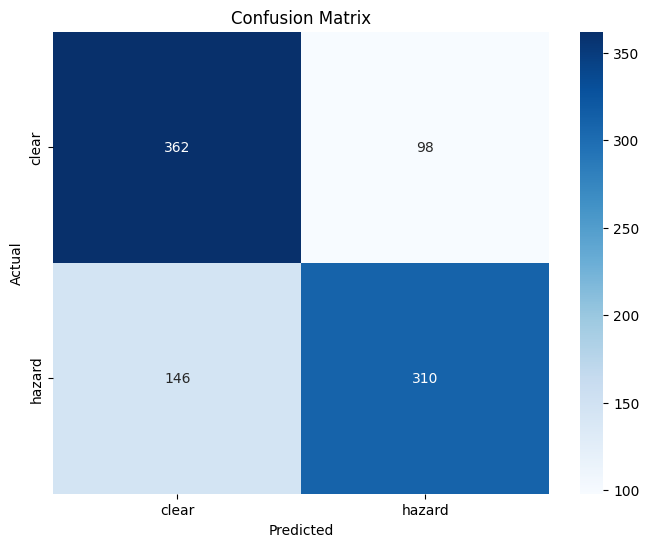

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

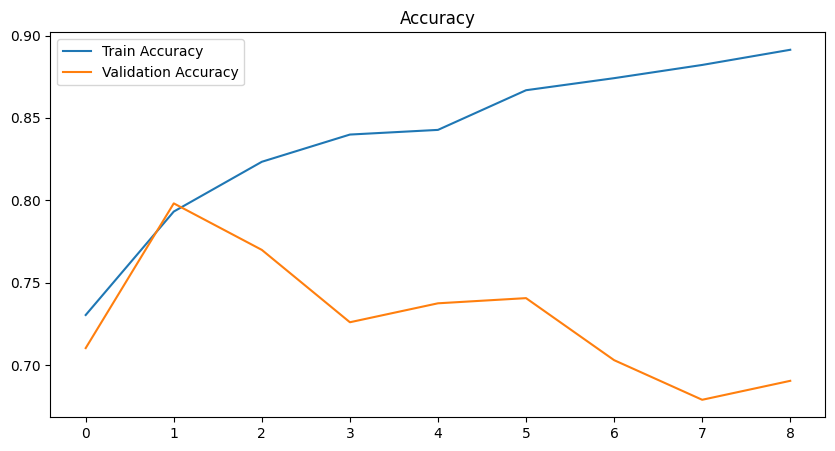

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.legend()
plt.title("Accuracy")

plt.show()

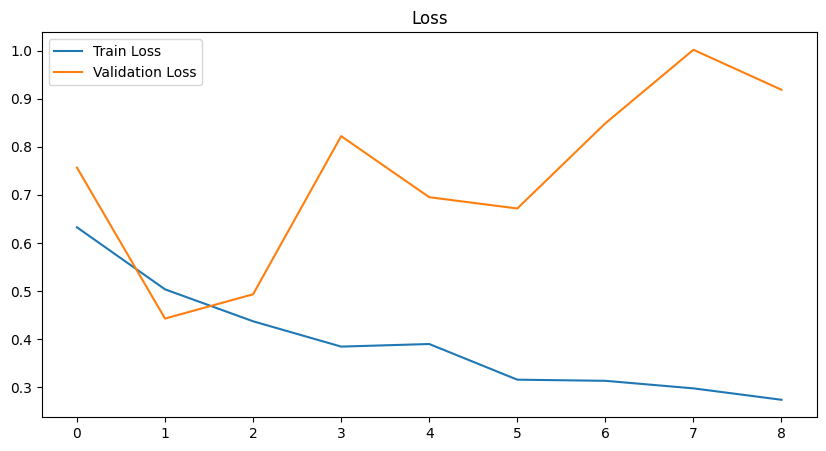

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.legend()
plt.title("Loss")

plt.show()